# Proyecto Final
## Clasificación automática y descubrimiento de sub-temas en quejas de consumidores financieros
**Camino B:** Supervisado + NLP + No supervisado + Dashboard Streamlit

Dataset: CFPB Consumer Complaint Database (2011–2019)

## 0. Dataset y alcance

- **Fuente:** CFPB Consumer Complaint Database.
- **Decisión clave:** `Consumer complaint narrative` está vacía en ~68–70% de filas → para NLP/clasificación usamos solo filas con narrativa.
- **Product:** unificamos categorías renombradas y nos quedamos con el **Top 7 + Otros**.
- **Objetivo de negocio:** enrutamiento automático de quejas + detección de sub-temas emergentes.

In [15]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from proyecto_utils import (
    DATA_DICTIONARY, DATA_PATH, MODELS_DIR, TOP_PRODUCTS, US_STATES_URL,
    add_derived_columns, clean_text, get_nlp_subset, load_raw_data,
    top_cluster_terms, top_terms_by_class, unify_product,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
MODELS_DIR.mkdir(exist_ok=True)

In [16]:
df_raw = load_raw_data()
df = add_derived_columns(df_raw)
print('Shape:', df.shape)
df.head()

Shape: (1282355, 14)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Product_unified,has_narrative,year,quarter
0,2019-05-10,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Bank account or service,False,2019,2019Q2
1,2019-05-10,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,Bank account or service,False,2019,2019Q2
2,2019-05-10,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,Debt collection,False,2019,2019Q2
3,2019-05-10,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,Credit reporting,False,2019,2019Q2
4,2019-05-10,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,Bank account or service,False,2019,2019Q2


## 1. Análisis de datos y metadatos (5%)

In [17]:
meta = pd.DataFrame({
    'columna': df.columns,
    'tipo': df.dtypes.astype(str).values,
    'nulos_%': (df.isna().mean() * 100).round(2).values,
})
meta['descripcion'] = meta['columna'].map(DATA_DICTIONARY)
meta

,columna,tipo,nulos_%,descripcion
0,Date received,datetime64[ns],0.00,Fecha en que el CFPB recibió la queja.
1,Product,object,0.00,Categoría principal del producto o servicio fi...
2,Sub-product,object,18.34,Subcategoría del producto.
3,Issue,object,0.00,Problema reportado por el consumidor.
4,Sub-issue,object,41.42,Detalle del problema dentro del Issue.
5,Consumer complaint narrative,object,70.09,Texto libre de la queja (puede estar vacío).
6,Company public response,object,64.98,Respuesta pública de la empresa (puede estar v...
7,Company,object,0.00,Institución financiera señalada.
8,State,object,1.51,Estado de EE.UU. del consumidor.
9,ZIP code,object,8.99,Código postal del consumidor.


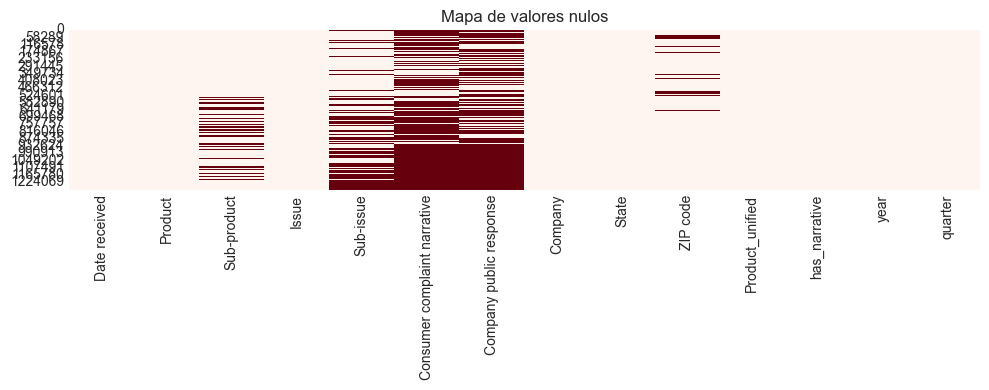

Duplicados exactos: 27070
Rango de fechas: 2011-12-01 00:00:00 → 2019-05-10 00:00:00


In [18]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, cmap='Reds')
plt.title('Mapa de valores nulos')
plt.tight_layout()
plt.show()

print('Duplicados exactos:', df.duplicated().sum())
print('Rango de fechas:', df['Date received'].min(), '→', df['Date received'].max())

**Interpretación metadatos:** La narrativa y la respuesta pública concentran la mayoría de nulos. Esto limita el NLP pero no impide el EDA agregado ni el enrutamiento parcial cuando sí hay texto.

In [19]:
print('Product original (top 10):')
print(df_raw['Product'].value_counts().head(10))

print('\nProduct unificado (top 10):')
print(df['Product_unified'].value_counts().head(10))

Product original (top 10):
Product
Mortgage                                                                        278098
Debt collection                                                                 244873
Credit reporting, credit repair services, or other personal consumer reports    225978
Credit reporting                                                                140432
Credit card                                                                      89190
Bank account or service                                                          86206
Student loan                                                                     51685
Credit card or prepaid card                                                      47653
Checking or savings account                                                      40641
Consumer Loan                                                                    31605
Name: count, dtype: int64

Product unificado (top 10):
Product_unified
Credit reporting        

**Unificación de categorías:** Se fusionaron variantes históricas de *Credit reporting*, *Credit card* y *Bank account or service* para evitar fragmentar una misma línea de negocio.

## 2. EDA — Exploratory Data Analysis (10%)

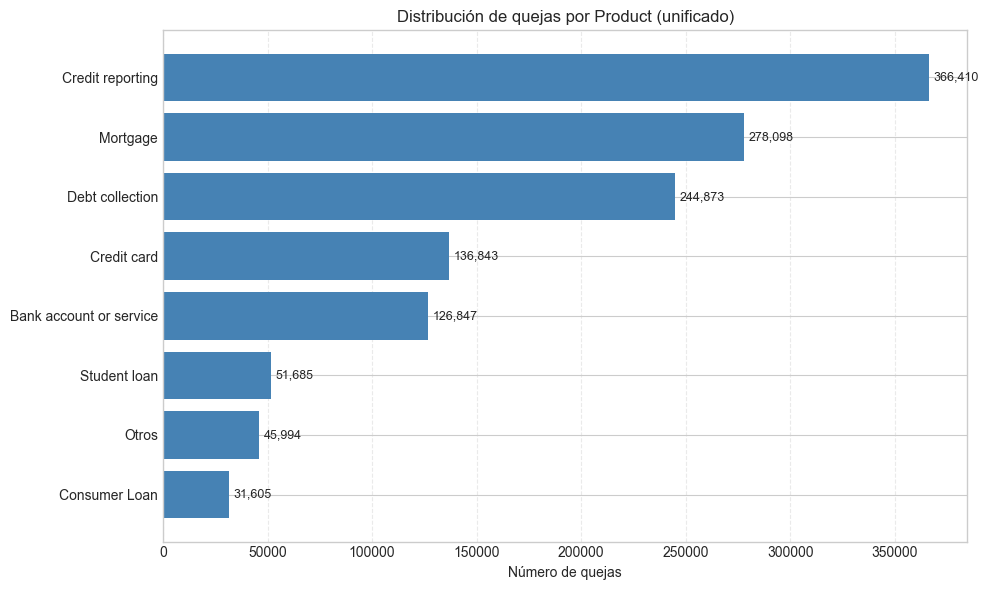

In [20]:
prod = df['Product_unified'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prod.index, prod.values, color='steelblue')
ax.set_title('Distribución de quejas por Product (unificado)')
ax.set_xlabel('Número de quejas')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretación:** *Credit reporting* y *Mortgage* dominan el volumen → prioridad para monitoreo regulatorio.

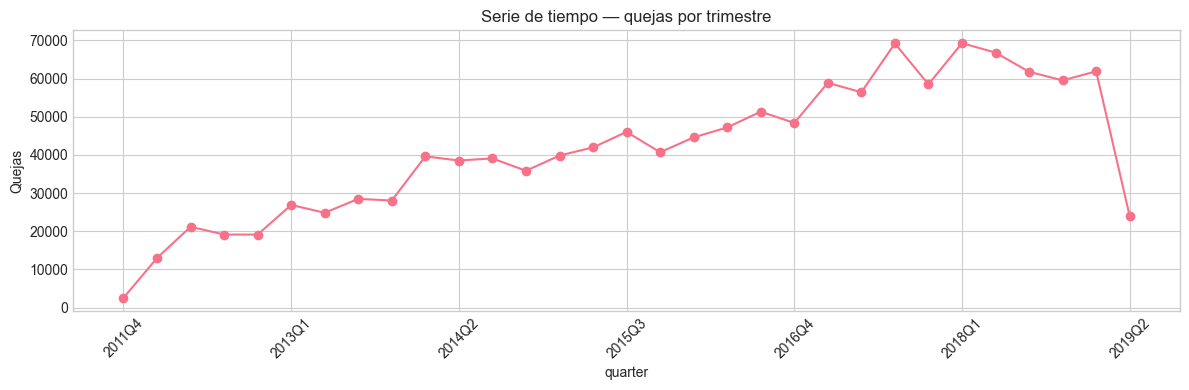

In [21]:
ts = df.groupby('quarter').size()
ts.plot(figsize=(12, 4), marker='o')
plt.title('Serie de tiempo — quejas por trimestre')
plt.ylabel('Quejas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretación:** El volumen crece hacia 2016–2018, coherente con mayor digitalización y visibilidad del CFPB.

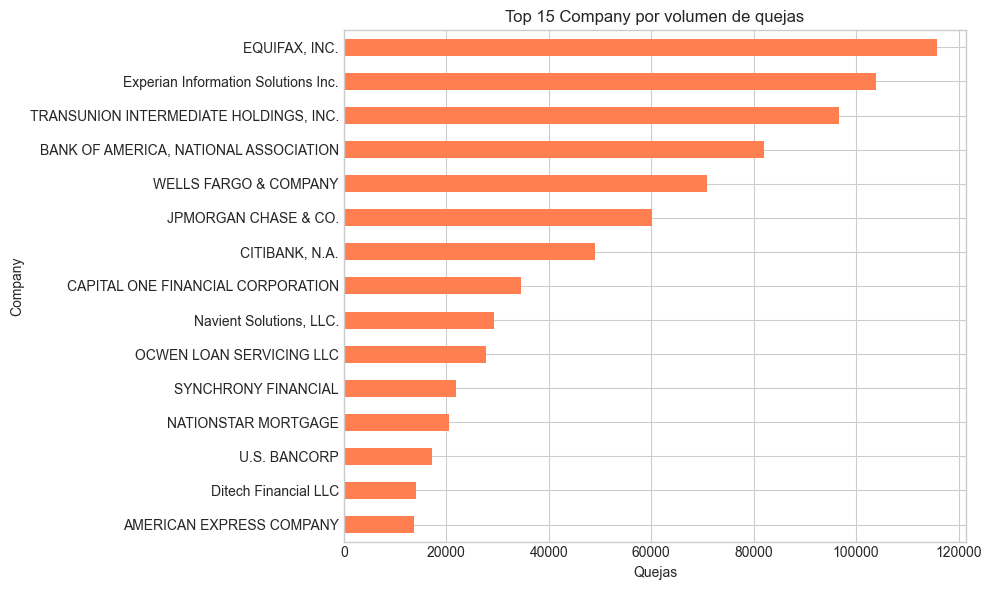

In [22]:
top_co = df['Company'].value_counts().head(15)
ax = top_co.plot(kind='barh', figsize=(10, 6), color='coral')
plt.title('Top 15 Company por volumen de quejas')
plt.xlabel('Quejas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

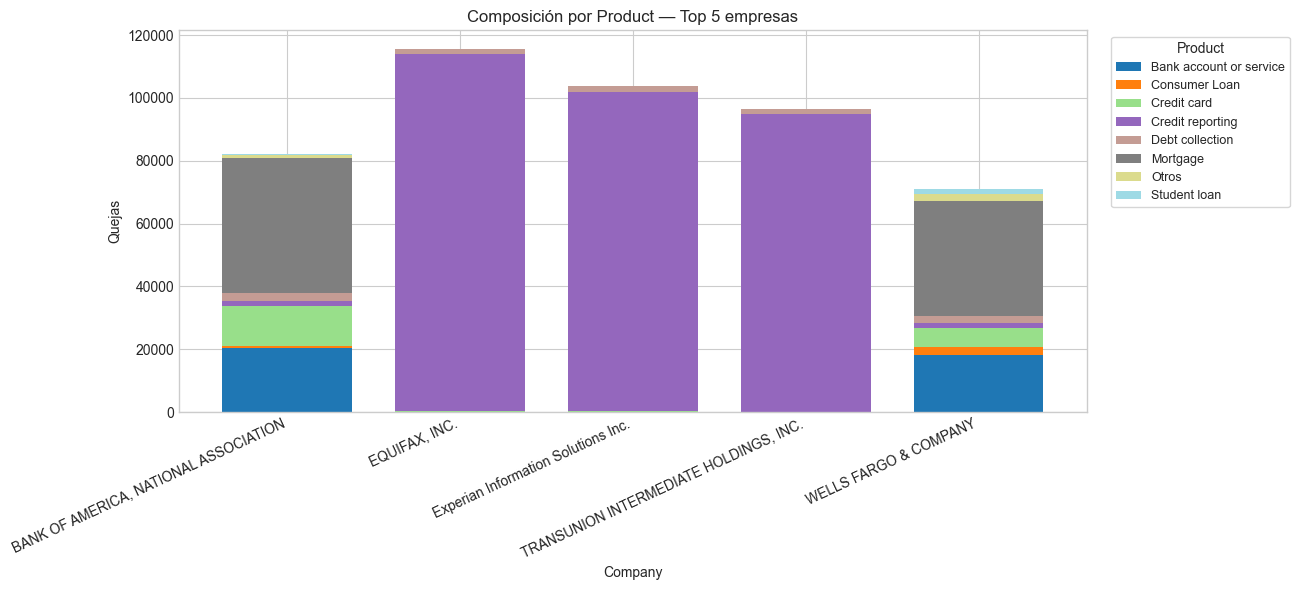

In [23]:
top5 = df['Company'].value_counts().head(5).index
comp_prod = (
    df[df['Company'].isin(top5)]
    .groupby(['Company', 'Product_unified'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 6))
comp_prod.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.75)
ax.set_title('Composición por Product — Top 5 empresas')
ax.set_ylabel('Quejas')
ax.set_xlabel('Company')
plt.xticks(rotation=25, ha='right')
ax.legend(
    title='Product',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=9,
    frameon=True,
)
plt.tight_layout()
plt.show()

**Interpretación:** Las grandes instituciones no comparten el mismo mix de Product → el clasificador debe ser robusto por texto, no solo por empresa.

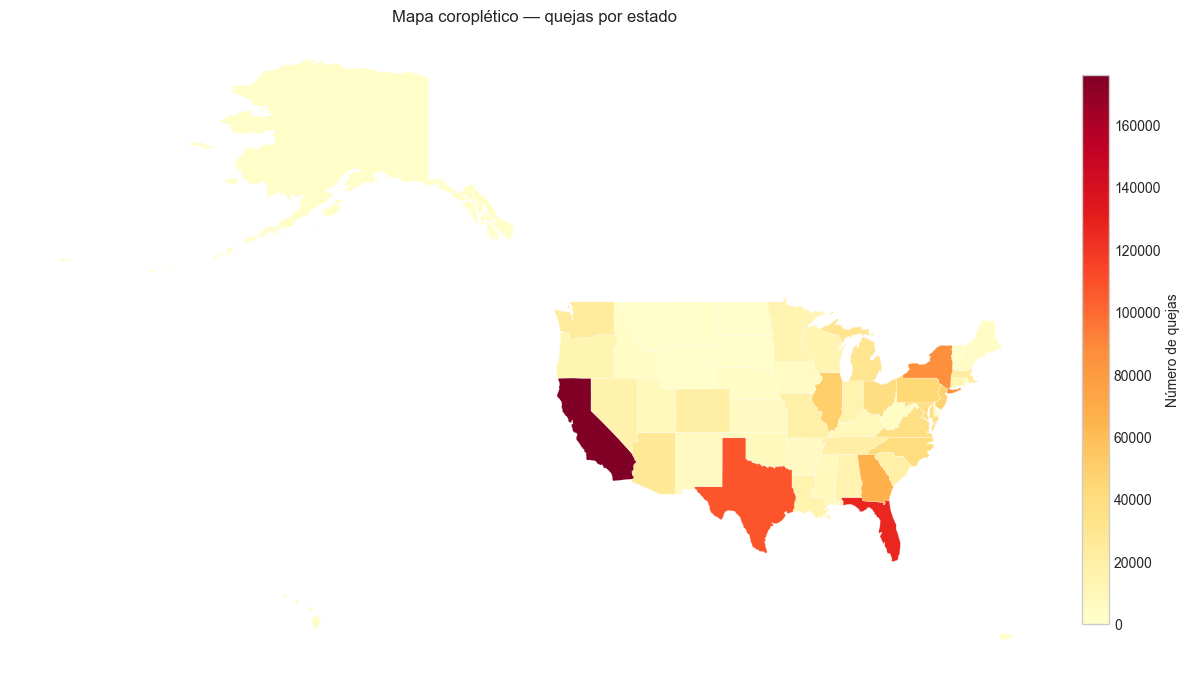

In [25]:
STATE_ABBR_TO_NAME = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas", "CA": "California",
    "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware", "FL": "Florida", "GA": "Georgia",
    "HI": "Hawaii", "ID": "Idaho", "IL": "Illinois", "IN": "Indiana", "IA": "Iowa",
    "KS": "Kansas", "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi", "MO": "Missouri",
    "MT": "Montana", "NE": "Nebraska", "NV": "Nevada", "NH": "New Hampshire", "NJ": "New Jersey",
    "NM": "New Mexico", "NY": "New York", "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio",
    "OK": "Oklahoma", "OR": "Oregon", "PA": "Pennsylvania", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah", "VT": "Vermont",
    "VA": "Virginia", "WA": "Washington", "WV": "West Virginia", "WI": "Wisconsin", "WY": "Wyoming",
    "DC": "District of Columbia",
}

states = gpd.read_file(US_STATES_URL)
state_counts = df.groupby('State').size().reset_index(name='quejas')
state_counts['name'] = state_counts['State'].map(STATE_ABBR_TO_NAME)
merged = states.merge(state_counts, on='name', how='left')
merged['quejas'] = merged['quejas'].fillna(0)

from matplotlib.colors import Normalize
from matplotlib import cm

fig, ax = plt.subplots(figsize=(12, 7))
merged.plot(
    column='quejas',
    ax=ax,
    cmap='YlOrRd',
    edgecolor='white',
    linewidth=0.2,
    legend=False,
)
norm = Normalize(vmin=merged['quejas'].min(), vmax=merged['quejas'].max())
sm = cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Número de quejas')
ax.set_title('Mapa coroplético — quejas por estado')
ax.axis('off')
plt.tight_layout()
plt.show()

**Interpretación:** CA, FL, TX y NY concentran gran parte del volumen, alineado con población y actividad financiera.

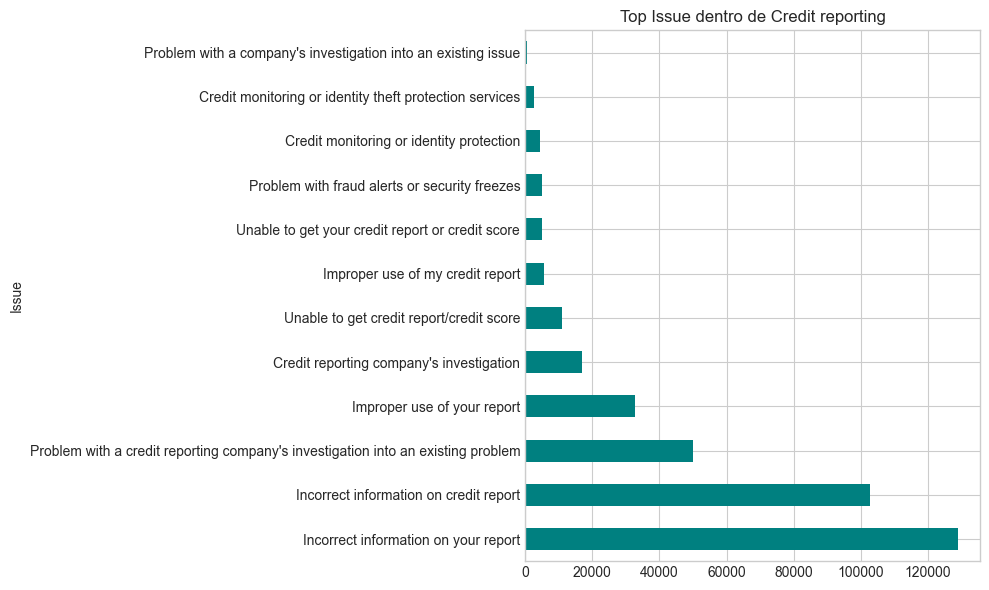

In [26]:
top_product = df['Product_unified'].value_counts().idxmax()
issue_top = df[df['Product_unified'] == top_product]['Issue'].value_counts().head(12)
issue_top.plot(kind='barh', figsize=(10, 6), color='teal')
plt.title(f'Top Issue dentro de {top_product}')
plt.tight_layout()
plt.show()

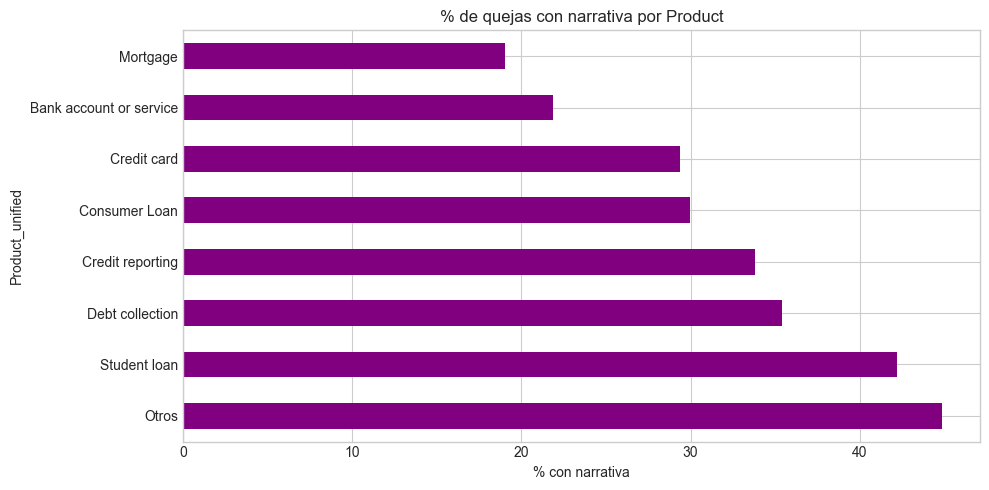

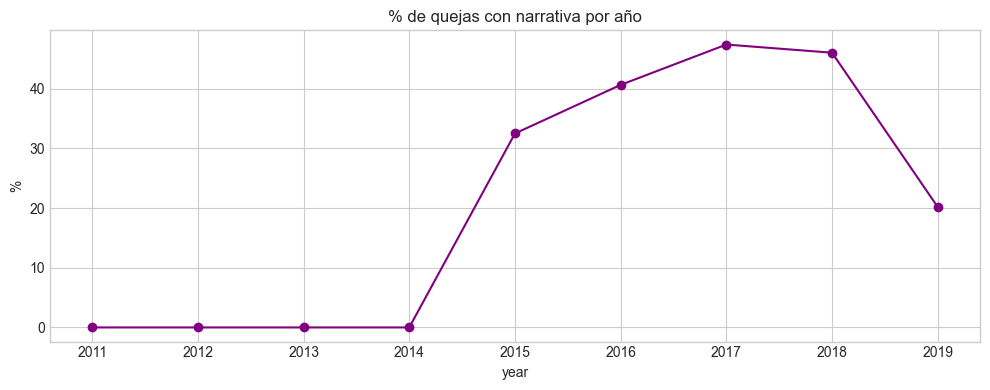

In [27]:
narr_by_prod = df.groupby('Product_unified')['has_narrative'].mean().sort_values(ascending=False) * 100
narr_by_prod.plot(kind='barh', figsize=(10, 5), color='purple')
plt.title('% de quejas con narrativa por Product')
plt.xlabel('% con narrativa')
plt.tight_layout()
plt.show()

narr_time = df.groupby('year')['has_narrative'].mean() * 100
narr_time.plot(figsize=(10, 4), marker='o', color='purple')
plt.title('% de quejas con narrativa por año')
plt.ylabel('%')
plt.tight_layout()
plt.show()

**Interpretación:** El porcentaje con narrativa varía por Product y aumenta en años recientes, reforzando la viabilidad del módulo NLP sobre un subconjunto creciente.

## 3. Propuesta de negocio (5%)

**Problema:** El triage manual de quejas es lento y costoso. Dentro de categorías grandes (p. ej. *Credit reporting*) pueden existir sub-problemas emergentes no capturados a tiempo por una taxonomía fija (*Sub-issue*).

**Propuesta:**
1. Clasificador automático que enrute cada queja nueva a *Product* en tiempo real a partir del texto libre.
2. Módulo no supervisado de sub-temas dentro del producto más grande, como alerta temprana de patrones nuevos.

**Beneficiarios:** CFPB/reguladores, bancos y aseguradoras, software de atención al cliente financiero.

**Métrica de éxito:** Reducción del tiempo de enrutamiento manual (p. ej. 40–60%) y detección de sub-temas emergentes semanas antes que el proceso manual.

## 4. Implementación de Ciencia de Datos (10%)

### 4a. NLP + Supervisado — Clasificación de Product

In [29]:
nlp_df = get_nlp_subset(df, sample_n=100_000, random_state=42)
nlp_df = nlp_df[nlp_df['Product_unified'] != 'Otros'].copy()
nlp_df['text_clean'] = nlp_df['Consumer complaint narrative'].map(clean_text)
print('Filas para NLP:', len(nlp_df))
print(nlp_df['Product_unified'].value_counts())

KeyboardInterrupt: 

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X = tfidf.fit_transform(nlp_df['text_clean'])
y = nlp_df['Product_unified']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=-1)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('F1 macro:', round(f1_score(y_test, y_pred, average='macro'), 4))
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=log_reg.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=log_reg.classes_, yticklabels=log_reg.classes_)
plt.title('Matriz de confusión — Logistic Regression')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
dt = DecisionTreeClassifier(max_depth=20, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print('Decision Tree — Accuracy:', round(accuracy_score(y_test, y_pred_dt), 4))
print('Decision Tree — F1 macro:', round(f1_score(y_test, y_pred_dt, average='macro'), 4))

In [ ]:
terms = top_terms_by_class(tfidf, log_reg, log_reg.classes_, n_terms=8)
terms.head(20)

In [ ]:
for product in log_reg.classes_[:3]:
    subset = terms[terms['Product'] == product].head(8)
    print(f'\n{product}:', ', '.join(subset['term'].tolist()))

**Interpretación supervisada:** TF-IDF + Regresión Logística alcanza buen desempeño macro-F1 pese al desbalance. Las palabras top por clase son interpretables y accionables para negocio (p. ej. *credit*, *report*, *loan*).

### 4b. No supervisado — Sub-temas en Credit reporting

In [ ]:
CLUSTER_PRODUCT = 'Credit reporting'
credit = df[(df['Product_unified'] == CLUSTER_PRODUCT) & df['has_narrative']].copy()
if len(credit) > 25000:
    credit = credit.sample(25000, random_state=42)
credit['text_clean'] = credit['Consumer complaint narrative'].map(clean_text)
print('Muestra clustering:', len(credit))

In [ ]:
tfidf_cl = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=5)
X_cl = tfidf_cl.fit_transform(credit['text_clean'])

scores = []
K_range = range(3, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cl)
    scores.append(silhouette_score(X_cl, labels))

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), scores, marker='o')
plt.title('Silhouette score vs k')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(scores))]
print('Mejor k:', best_k)

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cl)
cluster_terms = top_cluster_terms(tfidf_cl, kmeans.cluster_centers_)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cl.toarray())

plt.figure(figsize=(9, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', alpha=0.5, s=8)
plt.title('Clusters de sub-temas — Credit reporting (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

for cid, words in cluster_terms.items():
    print(f'Cluster {cid}:', ', '.join(words[:10]))

In [ ]:
compare = pd.DataFrame({'cluster': cluster_labels, 'Sub-issue': credit['Sub-issue'].fillna('Sin sub-issue')})
pd.crosstab(compare['cluster'], compare['Sub-issue']).iloc[:, :8]

**Interpretación no supervisada:** Los clusters recuperan patrones semánticos relacionados con Sub-issue oficiales, pero también agrupan quejas con etiquetas dispersas → potencial para detectar temas emergentes no catalogados.

## 5. Data Storytelling y visualización (5%)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Product_unified'].value_counts().head(6).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Hallazgo 1: Productos dominantes')
axes[0].tick_params(axis='x', rotation=30)

class_f1 = f1_score(y_test, y_pred, average=None, labels=log_reg.classes_)
pd.Series(class_f1, index=log_reg.classes_).sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Hallazgo 2: F1 por Product (clasificador)')
axes[1].set_xlabel('F1')
plt.suptitle('Resumen ejecutivo visual — CFPB Complaints', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Narrativa:** El volumen se concentra en crédito e hipotecas → un clasificador de texto reduce triage manual; el clustering complementa detectando sub-temas dentro del producto líder.

## 6. Conclusiones y aportaciones (5%)

**¿Se sostiene la hipótesis?** Sí, parcialmente: el clasificador supervisado enruta quejas con F1 macro sólido y el clustering revela sub-estructura útil dentro de *Credit reporting*.

**Limitaciones:** ~70% sin narrativa; desbalance de clases; datos hasta 2019; TF-IDF no captura contexto profundo.

**Próximos pasos:** Datos recientes, embeddings/BERT, integrar Sub-product como feature, despliegue en tiempo real.

**Aportación accionable:** Pipeline listo para enrutamiento automático + alertas tempranas de sub-temas para equipos de cumplimiento y atención al cliente.

## Exportar modelos para Streamlit

In [ ]:
joblib.dump(tfidf, MODELS_DIR / 'tfidf_vectorizer.joblib')
joblib.dump(log_reg, MODELS_DIR / 'product_classifier.joblib')
joblib.dump(log_reg.classes_.tolist(), MODELS_DIR / 'product_classes.joblib')
cluster_bundle = {
    'product': CLUSTER_PRODUCT,
    'vectorizer': tfidf_cl,
    'kmeans': kmeans,
    'pca': pca,
    'coords': coords,
    'labels': cluster_labels,
    'sub_issues': credit['Sub-issue'].fillna('Sin sub-issue').values,
    'silhouette': max(scores),
    'k': best_k,
    'cluster_terms': cluster_terms,
    'sample_size': len(credit),
}
joblib.dump(cluster_bundle, MODELS_DIR / 'cluster_bundle.joblib')
joblib.dump(df, MODELS_DIR / 'data_processed.joblib')
print('Modelos exportados en', MODELS_DIR)

## 7. Dashboard Streamlit

Ejecutar en terminal:

```bash
pip install -r requirements.txt
streamlit run dashboard.py
```